## Computational Psycholinguistics A3

#### Name - Namrata Baliga
#### Roll Number - 2022101021

In [1]:
import nltk
from nltk.stem import WordNetLemmatizer
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import nltk
import numpy as np 

In [2]:
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

merged = pd.read_csv('merged_new.tsv', sep='\t')
merged['lemma'] = merged['word'].apply(lambda w: lemmatizer.lemmatize(w.lower()))
print(merged)

lemma_group = merged.groupby('lemma').agg({
    'frequency': 'sum',
    'mean_RT': 'mean'
}).reset_index()

print(lemma_group)

lemma_group_sorted = lemma_group.sort_values(by='frequency', ascending=False).reset_index(drop=True)
lemma_group_sorted['rank'] = lemma_group_sorted.index + 1

[nltk_data] Downloading package wordnet to /Users/nammi/nltk_data...


     word     mean_RT  word_length word_lower   frequency  neg_log_prob  \
0     Age  396.264151            3        age     7241100      0.012572   
1      An  322.300000            2         an   576832090      0.008517   
2     And  325.407932            3        and  4873010095      0.009955   
3      As  331.271375            2         as  1139819594      0.000180   
4     But  344.603659            3        but   422070748      2.059823   
..    ...         ...          ...        ...         ...           ...   
68   well  332.932177            4       well   134592416      0.131372   
69   what  321.677637            4       what    87561320      2.674538   
70  where  325.875315            5      where   136128991      5.221415   
71   with  329.665022            4       with  1110064802      4.595932   
72   year  308.613333            4       year    73403129      0.616843   

         pred1       pred2 word_type  lemma  
0   340.581374  338.645898   content    age  
1   341

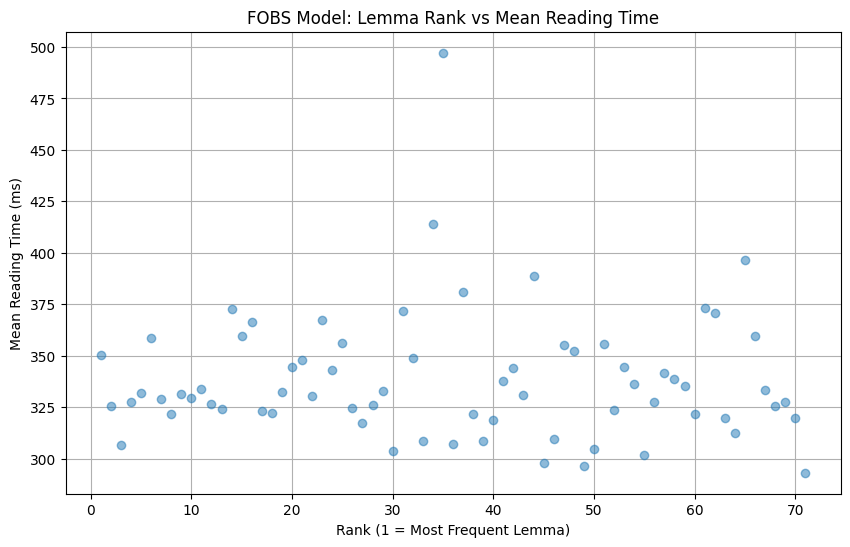

In [3]:
plt.figure(figsize=(10,6))
plt.plot(lemma_group_sorted['rank'], lemma_group_sorted['mean_RT'], marker='o', linestyle='none', alpha=0.5)
plt.xlabel('Rank (1 = Most Frequent Lemma)')
plt.ylabel('Mean Reading Time (ms)')
plt.title('FOBS Model: Lemma Rank vs Mean Reading Time')
plt.grid(True)
plt.show()

In [4]:
lemma_stats = merged.groupby('lemma').agg({
    'frequency': 'sum',
    'word': lambda x: x.iloc[0], 
}).reset_index()

lemma_stats['lemma_freq'] = lemma_stats['frequency']
lemma_stats['lemma_length'] = lemma_stats['lemma'].apply(len)



merged = pd.merge(merged, lemma_stats[['lemma', 'lemma_freq', 'lemma_length']], on='lemma', how='left', suffixes=('', '_new'))
# print(merged['lemma_freq'])
merged['log_frequency'] = np.log1p(merged['frequency'])
merged['log_lemma_freq'] = np.log1p(merged['lemma_freq'])


X1 = merged[['log_frequency', 'word_length']]
X1 = sm.add_constant(X1)
y = merged['mean_RT']

model1 = sm.OLS(y, X1).fit()
print(model1.summary())

X2 = merged[['log_lemma_freq', 'lemma_length']]
X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                mean_RT   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.2713
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.763
Time:                        19:29:55   Log-Likelihood:                -352.66
No. Observations:                  73   AIC:                             711.3
Df Residuals:                      70   BIC:                             718.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           355.1576     51.319      6.921

- Model 2 performed slightly better than Model 1 as it explained more variance in reading time, suggesting that root frequency is a better predictor of reading time than surface frequency.

In [5]:
merged_df = pd.read_csv('merged_df.tsv', sep='\t')
merged.to_csv('merged.tsv', sep='\t', index=False)


subset = merged_df[merged_df['word_lower'].isin([
    'bird', 'mother', 'king','bed' ,'good',
    'focused','called' , 'teacher', 'owed', 'flying' 
])]

print(subset)

from scipy.stats import ttest_ind

pseudo = subset[subset['word_lower'].isin(['bird', 'mother', 'king','bed' ,'good'])]['mean_RT']
real = subset[subset['word_lower'].isin(['focused','called' , 'teacher', 'side', 'flying' ])]['mean_RT']

t_stat, p_value = ttest_ind(pseudo, real)
print(f"T-stat: {t_stat:.3f}, p-value: {p_value:.3f}")

       word_x     mean_RT  word_length word_lower   word_y  frequency
79       Good  497.217391            4       good     good   99518711
320       bed  321.577869            3        bed      bed   17264116
341      bird  333.532740            4       bird     bird    4823924
404    called  337.665689            6     called   called   69300306
796    flying  325.703593            6     flying   flying    4200420
798   focused  373.583333            7    focused  focused    8093758
1018     king  370.885714            4       king     king   13253011
1168   mother  344.716867            6     mother   mother   39696579
1268     owed  293.150685            4       owed     owed    1830581
1761  teacher  315.313253            7    teacher  teacher   14634862
T-stat: 0.937, p-value: 0.380


- Results of hypothesis: T-stat: 0.937, p-value: 0.380

- The difference in mean reading times between real and pseudo-affixed words is not statistically significant.

- A p-value of 0.380 means there's a 38% chance that the observed (or more extreme) difference could arise under the null hypothesis (that there’s no difference). The data does not support the hypothesis that pseudo-affixed words require more processing time than true-affixed words.

- This result suggests that visual similarity to an affix (e.g., -er, -ed) is not sufficient to impact reading times, at least in this small sample.

